In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import os
import re
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
import statsmodels.api as sm
import statsmodels
from matplotlib.lines import Line2D
import scipy.stats as stats
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from scipy.spatial.distance import cosine
from scipy.stats import wilcoxon
import statsmodels.formula.api as smf

Raw data loading

In [2]:
os.chdir("C:/Users/user/Desktop/초거대AI/manuscript/publication/NPJ DIGIT MED/upload/replication")

In [8]:
### Data loading
raw_data = pd.read_csv("raw_data_emotions.csv").iloc[:, 1:] #Source cohort's counterfactual core affect ratings (emo_raw)
kor_data = pd.read_excel("mug_korean_samples_affect.xlsx").iloc[:, [2, 3, 5, 1, 6, 4]] #Validation cohort's counterfactual core affect ratings
image_response = pd.read_csv("image_coreaffects.csv").iloc[:, [1, 2, 4, 3, 5, 6]] #EVAL cohort's affective ratings of LLM-generated emotional images
text_response = pd.read_csv("text_coreaffects.csv").iloc[:, 1:] #Evaluation cohort's affective ratings of LLM-generated emotional texts (emo_text and emo_image)
pathology = pd.read_csv("factor_scores.csv")
pathology = pathology.iloc[:, 1:]
demographics = pd.read_csv("demographic_all2.csv") #EVAL cohort's demographics
demographics = demographics.iloc[:, 1:]
mug_kor_subj = list(np.unique(list(kor_data["participant"]))) # Validation cohort participants' core affect ratings (emo_KOR)

demographics['age_cleaned'] = demographics['age'].str.extract(r'(\d{2})', expand=False)

## Placeholders for emotion names
raw_emotion_order = ["happy", "sad", "afraid", "disgust", "anger", "surprise", "satisfied", "relaxed", "sleepy", 
                        "shame", "guilt", "embarrass", "pride", "r_anger", "contempt", "m_disgust", "elevation", "gratitude"]

raw_emotion_order_name = ['happy', 'sad', 'afraid', 'disgust', 'anger', 'surprise', 'satisfied', 'relaxed', 'sleepy', 'shame', 'guilt', 'embarrass',
 'pride', 'ranger', 'contempt', 'mdisgust', 'elevation', 'gratitude']

emotion_dict_english = {"감정 행복함" : "happy", 
                        "감정 슬픔" : "sad", 
                        "감정 두려움" : "afraid", 
                        "감정 혐오감" : "disgust", 
                        "감정 분노" : "anger", 
                        "감정 놀람" : "surprise", 
                        "감정 만족감" : "satisfied", 
                        "감정 편안함" : "relaxed", 
                        "감정 졸림" : "sleepy", 
                        "감정 수치심" : "shame", 
                        "감정 죄책감" : "guilt", 
                        "감정 당황/창피함" : "embarrass", 
                        "감정 자부심" : "pride", 
                        "감정 의로운 분노" : "r_anger", 
                        "감정 경멸" : "contempt", 
                        "감정 도덕적 혐오" : "m_disgust", 
                        "감정 고양감" : "elevation", 
                        "감정 감사" : "gratitude"
}

# Summed score calculation for six different questionnaires
# Null values of each questionnaire are filled with the mean value of the remaining items for the individual
# Null value filling is done separately for each of the forward/reward items of STAI-X1
# Dummy items for PFQ-2 are not integrated.

pathology["PHQ_sum"] = pathology.iloc[:, 1:10].fillna(pathology.iloc[:, 1:10].mean(axis = 1)).sum(axis = 1) - 9 # Depression severity score
pathology["GAD_sum"] = pathology.iloc[:, 10:17].fillna(pathology.iloc[:, 10:17].mean(axis = 1)).sum(axis = 1) - 7# Generalized anxiety score
stai_for = pathology.iloc[:, [19, 20, 22, 23, 25, 28, 29, 30, 33, 34,]] #Forward items of STAI-X1
stai_rev = pathology.iloc[:, [17, 18, 21, 24, 26, 27, 31, 32, 35, 36]] #Reverse items of STAI-X1
stai_for = stai_for.fillna(stai_for.mean(axis = 1))
stai_rev = stai_rev.fillna(stai_rev.mean(axis = 1))
pathology["STAI_sum"] = stai_for.sum(axis = 1) + (50 - stai_rev.sum(axis = 1)) # Reverse item scores are reversed from 1 - 4 to 4 - 1. 
pathology["ERQ_sum"] = pathology.iloc[:, 37:47].fillna(pathology.iloc[:, 37:47].mean(axis = 1)).sum(axis = 1) # Emotion regulation
pathology["PFQ_sum"] = pathology.iloc[:, 47:69].fillna(pathology.iloc[:, 47:69].mean(axis = 1)).sum(axis = 1) - pathology.iloc[:, [45, 49, 56]].fillna(pathology.iloc[:, [45, 49, 56]].mean(axis = 1)).sum(axis = 1) - 19 # Prosocial emotion sensitivity; dummy items are removed
pathology["MAIA_sum"] = pathology.iloc[:, 69:69+32].fillna(pathology.iloc[:, 69:69+32].mean(axis = 1)).sum(axis = 1) # Interoception awareness
pathology

,ID,PHQ_1,PHQ_2,PHQ_3,PHQ_4,PHQ_5,PHQ_6,PHQ_7,PHQ_8,PHQ_9,...,ERQ_sum,PFQ_sum,MAIA_sum,G_score,F1,F2,F3,F4,F5,F6
0,LLM278,2,3,2,2.0,4.0,2.0,4,2.0,3.0,...,40.0,34.0,141.0,-0.496260,-3.009399,0.437309,-2.061820,-0.110740,1.089075,-0.068825
1,LLM171,1,2,1,1.0,2.0,2.0,1,2.0,2.0,...,33.0,27.0,148.0,0.116569,-0.712932,-0.301336,-0.133597,-0.780854,0.979215,0.317427
2,LLM016,2,2,1,2.0,2.0,2.0,2,2.0,1.0,...,48.0,29.0,127.0,-0.295497,-1.615027,-0.587106,-0.805467,-0.309538,1.142542,-0.225659
3,LLM279,2,2,2,2.0,2.0,1.0,1,1.0,1.0,...,53.0,11.0,154.0,-0.004568,0.409165,0.067550,0.062857,-0.043289,0.024986,0.383722
4,LLM158,1,2,3,2.0,1.0,1.0,2,1.0,1.0,...,38.0,4.0,130.0,-0.763118,0.631437,-0.140389,-0.292434,0.102571,-0.039092,-0.100745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,LLM030,2,1,1,2.0,1.0,2.0,1,2.0,1.0,...,47.0,18.0,179.0,0.175878,0.047109,0.869926,-0.441919,0.123583,0.117925,0.476229
154,LLM099,2,2,1,2.0,1.0,1.0,1,1.0,1.0,...,55.0,13.0,161.0,-0.297691,-0.404386,1.368042,-0.799031,-0.877838,0.152914,0.244591
155,LLM130,1,1,2,2.0,2.0,1.0,1,1.0,1.0,...,51.0,3.0,154.0,-0.028153,1.117068,-0.125512,0.574674,-0.099418,-0.522474,0.727785
156,LLM083,1,1,2,2.0,1.0,1.0,1,1.0,1.0,...,45.0,4.0,179.0,0.320898,1.455032,0.372085,0.312553,0.960109,-0.525505,0.687967


In [7]:
len(np.unique(text_response["participant"]))

116

In [9]:
##Leave out participants who failed to provide de-identification numbers
subj_text = list(np.unique(text_response["participant"]))
subj_image = list(np.unique(image_response["participant"]))

pattern = r"^LLM\d{3}$"

subj_text_filtered = []
subj_image_filtered = []

print("number of participants who completed the main task : ", len(list(np.unique(text_response["participant"]))))

for item in subj_text:
    cleaned = item.strip()          # remove leading/trailing spaces
    if re.match(pattern, cleaned):  # check pattern
        subj_text_filtered.append(cleaned)

for item in subj_image:
    cleaned = item.strip()          # remove leading/trailing spaces
    if re.match(pattern, cleaned):  # check pattern
        subj_image_filtered.append(cleaned)

### Double-check by changing original dataframe IDs to have no space and just upper cases
for i in range(len(text_response)):
    item = text_response.iloc[i, 0]
    cleaned = item.strip()
    if re.match(pattern, cleaned):
        text_response.iloc[i, 0] = cleaned

for i in range(len(image_response)):
    item = image_response.iloc[i, 4]
    cleaned = item.strip()
    if re.match(pattern, cleaned):
        image_response.iloc[i, 4] = cleaned

for i in range(len(pathology)):
    item = pathology.iloc[i, 0]
    cleaned = item.strip()
    if re.match(pattern, cleaned):
        pathology.iloc[i, 0] = cleaned

subj_final = list(np.unique(pathology[pathology["ID"].isin(subj_text_filtered)]["ID"])) #intersection of those with all intact IDs
subj_final

print("##number of participants with relevant IDs : ", len(subj_final))

text_response = text_response[text_response["participant"].isin(subj_final)]
image_response = image_response[image_response["participant"].isin(subj_final)]

subj_text_final = list(np.unique(text_response["participant"]))#Final evaluation cohort with intact textual responses (n = 116)
subj_image_final = list(np.unique(image_response["participant"]))#Final evaluation cohort with intact image responses (n = 91)

print("number of participants after removing initial participants with image number assignment errors : ", len(subj_image_final))

subj_image_drop = []
for indiv in subj_text_final:
    if indiv not in subj_image_final:
        subj_image_drop.append(indiv)
print("number of the removed participants due to image number assignment errors : ", len(subj_image_drop))


number of participants who completed the main task :  138
##number of participants with relevant IDs :  116
number of participants after removing initial participants with image number assignment errors :  91
number of the removed participants due to image number assignment errors :  25


In [10]:
demographics = demographics[demographics["ID"].isin(subj_image_final)] #Final evaluation cohort (n = 91)
demographics

,Unnamed: 0,age,sex,education,marriage,occupation,language,ID,age_cleaned
0,0,29,0.0,1.0,1.0,2.0,0.0,LLM001,29
1,1,38,0.0,1.0,2.0,2.0,1.0,LLM002,38
12,12,30,0.0,1.0,1.0,2.0,0.0,LLM013,30
14,14,24,1.0,0.0,0.0,3.0,0.0,LLM015,24
15,15,41,0.0,1.0,2.0,3.0,0.0,LLM016,41
...,...,...,...,...,...,...,...,...,...
343,343,38,0.0,1.0,2.0,1.0,0.0,LLM344,38
352,352,만 21세,1.0,1.0,0.0,1.0,0.0,LLM353,21
356,356,38,1.0,1.0,1.0,1.0,0.0,LLM357,38
360,360,32,1.0,1.0,0.0,0.0,0.0,LLM361,32


In [11]:
# - image response sorting by emotion consstruct name ---------
for i in range(len(image_response)):
    if image_response.iloc[i, 5] == 'TTI_image_afraid10.png':
        image_response.iloc[i, 5] = 'afraid'
    if image_response.iloc[i, 5] == 'TTI_image_anger4.png':
        image_response.iloc[i, 5] = 'anger'
    if image_response.iloc[i, 5] == 'TTI_image_contempt5.png':
        image_response.iloc[i, 5] = 'contempt'
    if image_response.iloc[i, 5] == 'TTI_image_disgust1.png':
        image_response.iloc[i, 5] = 'disgust'
    if image_response.iloc[i, 5] == 'TTI_image_elevation5.png':
        image_response.iloc[i, 5] = 'elevation'
    if image_response.iloc[i, 5] == 'TTI_image_embarrass5.png':
        image_response.iloc[i, 5] = 'embarrass'
    if image_response.iloc[i, 5] == 'TTI_image_gratitude4.png':
        image_response.iloc[i, 5] = 'gratitude'
    if image_response.iloc[i, 5] == 'TTI_image_guilt4.png':
        image_response.iloc[i, 5] = 'guilt'
    if image_response.iloc[i, 5] == 'TTI_image_happy5.png':
        image_response.iloc[i, 5] = 'happy'
    if image_response.iloc[i, 5] == 'TTI_image_mdisgust1.png':
        image_response.iloc[i, 5] = 'm_disgust'
    if image_response.iloc[i, 5] == 'TTI_image_pride4.png':
        image_response.iloc[i, 5] = 'pride'
    if image_response.iloc[i, 5] == 'TTI_image_ranger1.png':
        image_response.iloc[i, 5] = 'r_anger'
    if image_response.iloc[i, 5] == 'TTI_image_relaxed2.png':
        image_response.iloc[i, 5] = 'relaxed'
    if image_response.iloc[i, 5] == 'TTI_image_sad5.png':
        image_response.iloc[i, 5] = 'sad'
    if image_response.iloc[i, 5] == 'TTI_image_satisfied9.png':
        image_response.iloc[i, 5] = 'satisfied'
    if image_response.iloc[i, 5] == 'TTI_image_shame2.png':
        image_response.iloc[i, 5] = 'shame'
    if image_response.iloc[i, 5] == 'TTI_image_sleepy2.png':
        image_response.iloc[i, 5] = 'sleepy'
    if image_response.iloc[i, 5] == 'TTI_image_surprise2.png':
        image_response.iloc[i, 5] = 'surprise'

In [12]:
text_response = text_response[text_response["participant"].isin(subj_image_final)] # text response of final evaluation cohort (n = 91)
image_response = image_response[image_response["participant"].isin(subj_image_final)] #image reponse of final evaluation cohort (n = 91)
image_response

,valence_image,arousal_image,focus_image,dominance_image,participant,stimulus_image
0,-44,69,199,215,LLM140,surprise
1,223,158,-223,-240,LLM140,pride
2,-193,-20,169,-247,LLM140,embarrass
3,219,30,-181,-221,LLM140,satisfied
4,-18,234,226,-234,LLM140,r_anger
...,...,...,...,...,...,...
1995,158,36,-45,2,LLM171,happy
1996,106,0,-22,-1,LLM171,elevation
1997,-199,-42,4,-192,LLM171,shame
1998,-176,115,145,-144,LLM171,r_anger


In [13]:
## Prepare evaluation group's core affect response ratings for each emotion
# Core affect responses to emotional texts
text_response_happy = text_response[text_response["text_order"].isin(range(0, 10))].iloc[:, :-2].reset_index(drop = True)
text_response_sad = text_response[text_response["text_order"].isin(range(10, 20))].iloc[:, :-2].reset_index(drop = True)
text_response_satisfied = text_response[text_response["text_order"].isin(range(20, 30))].iloc[:, :-2].reset_index(drop = True)
text_response_contempt = text_response[text_response["text_order"].isin(range(30, 40))].iloc[:, :-2].reset_index(drop = True)
text_response_anger = text_response[text_response["text_order"].isin(range(40, 50))].iloc[:, :-2].reset_index(drop = True)
text_response_pride = text_response[text_response["text_order"].isin(range(50, 60))].iloc[:, :-2].reset_index(drop = True)
text_response_guilt = text_response[text_response["text_order"].isin(range(60, 70))].iloc[:, :-2].reset_index(drop = True)
text_response_shame = text_response[text_response["text_order"].isin(range(70, 80))].iloc[:, :-2].reset_index(drop = True)
text_response_sleepy = text_response[text_response["text_order"].isin(range(80, 90))].iloc[:, :-2].reset_index(drop = True)
text_response_embarrass = text_response[text_response["text_order"].isin(range(90, 100))].iloc[:, :-2].reset_index(drop = True)
text_response_gratitude = text_response[text_response["text_order"].isin(range(100, 110))].iloc[:, :-2].reset_index(drop = True)
text_response_surprise = text_response[text_response["text_order"].isin(range(110, 120))].iloc[:, :-2].reset_index(drop = True)
text_response_afraid = text_response[text_response["text_order"].isin(range(120, 130))].iloc[:, :-2].reset_index(drop = True)
text_response_relaxed = text_response[text_response["text_order"].isin(range(130, 140))].iloc[:, :-2].reset_index(drop = True)
text_response_disgust = text_response[text_response["text_order"].isin(range(140, 150))].iloc[:, :-2].reset_index(drop = True)
text_response_m_disgust = text_response[text_response["text_order"].isin(range(150, 160))].iloc[:, :-2].reset_index(drop = True)
text_response_r_anger = text_response[text_response["text_order"].isin(range(160, 170))].iloc[:, :-2].reset_index(drop = True)
text_response_elevation = text_response[text_response["text_order"].isin(range(170, 180))].iloc[:, :-2].reset_index(drop = True)
# Core affect responses to emotional images
image_response_happy = image_response[image_response["stimulus_image"] == "happy"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_sad = image_response[image_response["stimulus_image"] == "sad"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_satisfied = image_response[image_response["stimulus_image"] == "satisfied"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_contempt = image_response[image_response["stimulus_image"] == "contempt"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_anger = image_response[image_response["stimulus_image"] == "anger"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_pride = image_response[image_response["stimulus_image"] == "pride"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_guilt = image_response[image_response["stimulus_image"] == "guilt"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_shame = image_response[image_response["stimulus_image"] == "shame"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_sleepy = image_response[image_response["stimulus_image"] == "sleepy"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_embarrass = image_response[image_response["stimulus_image"] == "embarrass"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_gratitude = image_response[image_response["stimulus_image"] == "gratitude"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_surprise = image_response[image_response["stimulus_image"] == "surprise"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_afraid = image_response[image_response["stimulus_image"] == "afraid"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_relaxed = image_response[image_response["stimulus_image"] == "relaxed"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_disgust = image_response[image_response["stimulus_image"] == "disgust"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_m_disgust = image_response[image_response["stimulus_image"] == "m_disgust"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_r_anger = image_response[image_response["stimulus_image"] == "r_anger"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)
image_response_elevation = image_response[image_response["stimulus_image"] == "elevation"].iloc[:, [4, 0, 1, 2, 3]].reset_index(drop = True)

### Evaluation group's Averaged core affect responses to emotional images
for i in range(18):
    name = raw_emotion_order[i]
    data = globals()["text_response_{}".format(name)]
    globals()["text_mean_{}_filtered".format(name)] = data.iloc[:, 1:].mean(axis = 0)

for i in range(18):
    name = raw_emotion_order[i]
    data = globals()["image_response_{}".format(name)]
    globals()["image_mean_{}_filtered".format(name)] = data.iloc[:, 1:].mean(axis = 0)

Table 1 Summary of participants’ demographic and psychopathology characteristics

In [14]:
### Descriptive statistics for Demography
print("number of participants with demographic data : ", len(demographics))
print("mean age : ", np.round(np.array(demographics["age_cleaned"].dropna()).astype(float).mean(), 1), " stdev of age : ", np.round(np.array(demographics["age_cleaned"].dropna()).astype(float).std(),1))
print(demographics["age_cleaned"].dropna().describe())
print(demographics.iloc[:, 1].value_counts())
print(demographics.iloc[:, 2].value_counts())
print(demographics.iloc[:, 3].value_counts())
print(demographics.iloc[:, 4].value_counts())
print(demographics.iloc[:, 5].value_counts())
print(demographics.iloc[:, 6].value_counts())

### Descriptive statistics for psychopathology ratings
print("number of participants with pathology ratings and intact ID during task : ", np.round(pathology[pathology["ID"].isin(subj_image_final)].iloc[:, -13:-7].count(), 1))
print("mean values for summed pathology scores") #PFQ-2 scores contain null items, requiring subtraction of 19. 
print(np.round(pathology[pathology["ID"].isin(subj_image_final)].iloc[:, -13:-7].mean(), 1))
print("stdev for summed pathology scores")
print(np.round(pathology[pathology["ID"].isin(subj_image_final)].iloc[:, -13:-7].std(), 1))

number of participants with demographic data :  91
mean age :  31.1  stdev of age :  8.6
count     91
unique    29
top       30
freq       9
Name: age_cleaned, dtype: object
age
30       9
21       8
33       6
24       5
36       5
31       4
38       4
34       4
32       4
20       4
23       3
25       3
28       3
29       3
35       3
39       2
50       2
20세      2
45       2
27       2
만26세     1
만 21세    1
44       1
32살      1
26세      1
19       1
22       1
59       1
46       1
52       1
54       1
41       1
48       1
Name: count, dtype: int64
sex
0.0    59
1.0    29
Name: count, dtype: int64
education
1.0    52
0.0    28
2.0    10
3.0     1
Name: count, dtype: int64
marriage
1.0    38
0.0    38
2.0    14
3.0     1
Name: count, dtype: int64
occupation
3.0    34
2.0    33
1.0    18
0.0     6
Name: count, dtype: int64
language
0.0    89
1.0     1
Name: count, dtype: int64
number of participants with pathology ratings and intact ID during task :  PHQ_sum     91
GAD_sum   

In [15]:
### Function for calculating Within-participant cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

def get_similarity_stereotypy(participant_df):
    """
    Calculates the average pairwise cosine similarity between all emotions responses.
    Higher Score = More Stereotyped (Clustered).
    Lower Score = More Diverse.
    """
    # 1. Get the 4D core affect coordinates
    coords = participant_df.values.astype(float)
    
    # 2. Calculate Cosine Similarity Matrix ((n - 1) x (n - 1) for n core affect response per each emotion and individual)
    # This gives the similarity of every emotion to every other emotion
    sim_matrix = cosine_similarity(coords)
    
    # 3. Extract the upper triangle (excluding the diagonal)
    # We don't want to compare self-self similarity
    # triu_indices returns the indices for the upper triangle
    upper_tri_indices = np.triu_indices_from(sim_matrix, k=1)
    unique_pairs = sim_matrix[upper_tri_indices]
    
    # 4. Calculate the Mean Similarity
    mean_similarity = np.mean(unique_pairs)
    std_similarity = np.std(unique_pairs)
    
    return mean_similarity

In [17]:
df_emo_raw_mean = pd.DataFrame(index = raw_emotion_order, columns = ["val", "aro", "foc", "dom"])
for i in range(18):
    name = raw_emotion_order[i]
    data = raw_data[raw_data["label"] == name].iloc[:, :-1]
    data_mean = data.mean(axis = 0)
    df_emo_raw_mean.iloc[i, :] = data_mean
df_emo_raw_mean

,val,aro,foc,dom
happy,160.638026,70.572212,-124.428702,-98.034735
sad,-171.372943,-40.850091,-35.420475,79.067642
afraid,-157.522852,29.389397,21.138026,117.687386
disgust,-177.484461,3.696527,67.870201,50.159963
anger,-154.86106,72.04936,69.241316,73.126143
surprise,66.956124,102.617916,-33.363803,46.846435
satisfied,160.171846,-19.473492,-150.59415,-138.368373
relaxed,154.003656,-93.723949,-165.447898,-151.622486
sleepy,25.506399,-101.292505,-137.568556,15.767824
shame,-168.555759,7.095064,-46.160878,75.639854


In [ ]:
aaa = text_response.dropna().groupby(["participant", "emotion_name"])[["valence_text", "arousal_text", "focus_text", "dominance_text"]]
coords = participant_df.values.astype(float)
sim_matrix = cosine_similarity(coords)
upper_tri_indices = np.triu_indices_from(sim_matrix, k=1)
unique_pairs = sim_matrix[upper_tri_indices]
    
# 4. Calculate the Mean Similarity
mean_similarity = np.mean(unique_pairs)
std_similarity = np.std(unique_pairs)

In [18]:
coords = df_emo_raw_mean.values.astype(float)
sim_matrix = cosine_similarity(coords)
upper_tri_indices = np.triu_indices_from(sim_matrix, k=1)
between_sims = sim_matrix[upper_tri_indices]
between_sims

array([-0.72736395, -0.79128479, -0.89557005, -0.75903537,  0.54870442,
        0.92011294,  0.78733686,  0.30537273, -0.62707763, -0.52720371,
       -0.55491845,  0.99068051, -0.61249315, -0.64656652, -0.88442094,
        0.98813016,  0.84862748,  0.87513248,  0.8247443 ,  0.69167582,
       -0.40568497, -0.6307897 , -0.50768706,  0.17285611,  0.96791737,
        0.94348023,  0.94634703, -0.7150805 ,  0.44055119,  0.37226657,
        0.63286825, -0.65747504, -0.89920488,  0.90087677,  0.922763  ,
       -0.10062807, -0.86920517, -0.84017089, -0.23204556,  0.91039351,
        0.82938512,  0.89102407, -0.83074283,  0.75629829,  0.480817  ,
        0.78508303, -0.71001244, -0.9910847 ,  0.92674278, -0.42918749,
       -0.89175635, -0.82205659, -0.39442437,  0.81702349,  0.764994  ,
        0.76545575, -0.88637502,  0.81363728,  0.78993774,  0.95862617,
       -0.81688898, -0.90733027, -0.06929612, -0.905169  , -0.93111765,
       -0.57050334,  0.76616013,  0.695149  ,  0.73755825, -0.79

In [19]:
between_sims.sort()
between_sims

array([-0.9910847 , -0.93111765, -0.90803588, -0.90781049, -0.90733027,
       -0.905169  , -0.90097408, -0.89920488, -0.89557005, -0.89175635,
       -0.88830416, -0.88637502, -0.88442094, -0.8733217 , -0.87324563,
       -0.86920517, -0.8608865 , -0.84017089, -0.83074283, -0.82382134,
       -0.82205659, -0.81794777, -0.81688898, -0.81337388, -0.79445002,
       -0.79128479, -0.78919859, -0.78730943, -0.75903537, -0.72736395,
       -0.7150805 , -0.71001244, -0.6992118 , -0.69874162, -0.66115413,
       -0.65747504, -0.65079035, -0.65015405, -0.64656652, -0.63358812,
       -0.6307897 , -0.62745243, -0.62707763, -0.61745112, -0.61249315,
       -0.60986318, -0.59941343, -0.57244931, -0.57050334, -0.5681001 ,
       -0.56433586, -0.55518411, -0.55491845, -0.52849101, -0.52720371,
       -0.51791934, -0.51762057, -0.51103753, -0.50768706, -0.50155647,
       -0.49487881, -0.46841386, -0.45194447, -0.43273748, -0.43039133,
       -0.42918749, -0.41857406, -0.40568497, -0.39442437, -0.24

In [22]:
def cosine_sim(a, b):
    """Cosine similarity between two vectors."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

def get_sims(ref, vecs):
    """Cosine similarity of each row in vecs to ref. Returns (N,) array."""
    return np.array([cosine_sim(ref, v) for v in vecs])

def fdr(pvals):
    from statsmodels.stats.multitest import multipletests
    _, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")
    return pvals_fdr

def mean_cosine_sim_to_ref(ref_vec, response_matrix):
    """
    Mean cosine similarity of response_matrix rows to ref_vec.
    ref_vec        : (4,)
    response_matrix: (N, 4)
    Returns scalar mean cosine similarity.
    """
    sims = np.array([cosine_sim(ref_vec, v) for v in response_matrix])
    return sims.mean(), sims.std(ddof=1), sims

In [ ]:
"""
Affective Alignment Analysis: LLM-Generated Stimuli vs Raw Emotion Vectors
===========================================================================
 
Narrative / Analysis Pipeline:
  Step 1. H0 vs 0     : Is mean cosine similarity > 0?
                         (LLM stimuli evoke non-random, colinear affective response)
  Step 2. H1 vs ε     : Is mean cosine similarity > epsilon?
                         (Does alignment reach within-cohort affective distinction threshold?)
  Step 3. Equivalence : TOST (sensitivity: k=0.25,0.5,1.0 × bc_std) + Cohen's d (pooled SD)
                         (Is the gap from epsilon negligible or meaningful?)

Data assumptions:
-----------------
  emo_raw_mean : (18, 4)    per-emotion mean of source group vectors
  emo_text     : 18 * (91, 4) per-participant, per-emotion mean across 10 texts
  emo_image    : 18 * (91, 4) per-participant, per-emotion image response
  between_sims : (153,)     all pairwise between-construct cosine similarities
"""


# =============================================================================
# Utility
# =============================================================================
 
def cosine_sim(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 1e-10 else 0.0
 
 

 


# =============================================================================
# Step 1. H0 vs 0
#   One-sample one-sided t-test: mean_sim > 0
#   H0: mean_sim <= 0   (orthogonal / random response)
#   H1: mean_sim >  0   (colinear response)
# =============================================================================
 
def test_H0_vs_zero(emo_raw_mean, emo_text, emo_image):
    rows = {}
    ref  = emo_raw_mean[i]
    t_s  = get_sims(ref, emo_text[:, :])
    im_s = get_sims(ref, emo_image[:, :])
 
    t_t,  t_p  = stats.ttest_1samp(t_s,  popmean=0, alternative="greater")
    im_t, im_p = stats.ttest_1samp(im_s, popmean=0, alternative="greater")
 
    rows.append(dict(
        emotion        = emo,
        text_mean_sim  = t_s.mean(),
        text_sd        = t_s.std(ddof=1),
        text_t         = t_t,
        text_p         = t_p,
        image_mean_sim = im_s.mean(),
        image_sd       = im_s.std(ddof=1),
        image_t        = im_t,
        image_p        = im_p
        ))
    
    return rows



### Table 3. One-sample one-sided t-tests revealed that mean cosine similarities between evaluation group affective responses and source group raw emotion vectors were significantly greater than zero for both text- and image-based formats, indicating non-orthogonal affective responses

In [31]:
N_EMOTIONS = len(raw_emotion_order)
ALPHA          = 0.05
RANDOM_SEED    = 42
TOST_K_VALUES  = [0.25, 0.5, 1.0]   # sensitivity analysis multipliers
rows_colinear = []
for i, emo in enumerate(raw_emotion_order):
    ref = df_emo_raw_mean.iloc[i, :]    
    text_vecs  = np.array(globals()["text_response_{}".format(emo)].groupby(["participant"]).mean())             # (91, 4)
    image_vecs = np.array(globals()["image_response_{}".format(emo)].iloc[:, [1,2,3,4]])            # (91, 4)
    #row_colinear = test_H0_vs_zero(ref, text_vecs, image_vecs)
    #rows_colinear.append(row_colinear)
    t_s  = get_sims(ref, text_vecs)
    im_s = get_sims(ref, image_vecs)
 
    t_t,  t_p  = stats.ttest_1samp(t_s,  popmean=0, alternative="greater")
    im_t, im_p = stats.ttest_1samp(im_s, popmean=0, alternative="greater")
 
    rows_colinear.append(dict(
        emotion        = emo,
        text_mean_sim  = t_s.mean(),
        text_sd        = t_s.std(ddof=1),
        text_t         = t_t,
        text_p         = t_p,
        image_mean_sim = im_s.mean(),
        image_sd       = im_s.std(ddof=1),
        image_t        = im_t,
        image_p        = im_p
        ))
df_colinear = pd.DataFrame(rows_colinear)
df_colinear["text_p_fdr"] = fdr(df_colinear["text_p"])
df_colinear["image_p_fdr"] = fdr(df_colinear["image_p"])
df_colinear["text_colinear"] = df_colinear["text_p_fdr"]  < ALPHA
df_colinear["image_colinear"] = df_colinear["image_p_fdr"] < ALPHA
np.round(df_colinear, 2)

,emotion,text_mean_sim,text_sd,text_t,text_p,image_mean_sim,image_sd,image_t,image_p,text_p_fdr,image_p_fdr,text_colinear,image_colinear
0,happy,0.61,0.34,17.23,0.00,0.46,0.44,9.89,0.0,0.00,0.0,True,True
1,sad,0.21,0.40,5.05,0.00,0.28,0.29,9.43,0.0,0.00,0.0,True,True
2,afraid,0.36,0.43,7.91,0.00,0.35,0.38,8.89,0.0,0.00,0.0,True,True
3,disgust,0.60,0.42,13.55,0.00,0.55,0.36,14.37,0.0,0.00,0.0,True,True
4,anger,0.50,0.50,9.59,0.00,0.44,0.40,10.59,0.0,0.00,0.0,True,True
5,surprise,0.43,0.44,9.17,0.00,0.40,0.42,9.03,0.0,0.00,0.0,True,True
6,satisfied,0.73,0.36,19.24,0.00,0.44,0.45,9.19,0.0,0.00,0.0,True,True
7,relaxed,0.77,0.30,24.20,0.00,0.64,0.40,15.26,0.0,0.00,0.0,True,True
8,sleepy,0.47,0.37,12.14,0.00,0.50,0.41,11.71,0.0,0.00,0.0,True,True
9,shame,0.17,0.44,3.78,0.00,0.33,0.32,9.89,0.0,0.00,0.0,True,True


In [33]:
# =============================================================================
# Step 2. H1 vs epsilon
#   One-sample one-sided t-test: mean_sim > epsilon
#   epsilon = 75th percentile of between-construct cosine similarities
#   Rationale: alignment must exceed the similarity of the top-25% most
#              similar emotion pairs to demonstrate target-specific reproduction
# =============================================================================

def compute_epsilon(between_sims, method="percentile_75"):
    if method == "percentile_75":
        epsilon = float(np.percentile(between_sims, 75))
    elif method == "percentile_90":
        epsilon = float(np.percentile(between_sims, 90))
    elif method == "median":
        epsilon = float(np.median(between_sims))
    else:
        raise ValueError(f"Unknown method: {method}")
 
    print(f"\n[Epsilon]")
    print(f"  Between-construct sim: mean={between_sims.mean():.4f}, "
          f"sd={between_sims.std():.4f}, "
          f"min={between_sims.min():.4f}, max={between_sims.max():.4f}")
    print(f"  epsilon ({method}) = {epsilon:.4f}")
    return epsilon

In [35]:
between_sims_75 = compute_epsilon(between_sims, method = "percentile_75")
between_sims_90 = compute_epsilon(between_sims, method = "percentile_90")
between_sims_50 = compute_epsilon(between_sims, method = "median")
print(between_sims_75, between_sims_90, between_sims_50)


[Epsilon]
  Between-construct sim: mean=0.0191, sd=0.7032, min=-0.9911, max=0.9953
  epsilon (percentile_75) = 0.7662

[Epsilon]
  Between-construct sim: mean=0.0191, sd=0.7032, min=-0.9911, max=0.9953
  epsilon (percentile_90) = 0.9182

[Epsilon]
  Between-construct sim: mean=0.0191, sd=0.7032, min=-0.9911, max=0.9953
  epsilon (median) = -0.0228
0.7661601283379215 0.9181690530069544 -0.022823046953787042


In [53]:
row_alignment = []
for i, emo in enumerate(raw_emotion_order): 
    ref = df_emo_raw_mean.iloc[i, :]    
    text_vecs  = np.array(globals()["text_response_{}".format(emo)].groupby(["participant"]).mean())             # (91, 4)
    image_vecs = np.array(globals()["image_response_{}".format(emo)].iloc[:, [1,2,3,4]])            # (91, 4)

    text_mean,  text_sd,  text_sims  = mean_cosine_sim_to_ref(ref, text_vecs)
    image_mean, image_sd, image_sims = mean_cosine_sim_to_ref(ref, image_vecs)

    t_text,  p_text  = stats.ttest_1samp(text_sims,  popmean=between_sims_90, alternative='greater')
    t_image, p_image = stats.ttest_1samp(image_sims, popmean=between_sims_90, alternative='greater')

    row_alignment.append({
        "emotion"       : emo,
        "epsilon" : between_sims_90,
        "method" : "90th percentile",
        "text_mean_sim" : text_mean,
        "text_sd"       : text_sd,
        "text_t"        : t_text,
        "text_p"        : p_text,
        "text_pass"     : p_text < ALPHA,
        "image_mean_sim": image_mean,
        "image_sd"      : image_sd,
        "image_t"       : t_image,
        "image_p"       : p_image,
        "image_pass"    : p_image < ALPHA,
        })
df_alignment = pd.DataFrame(row_alignment)

df_alignment["text_p_fdr"] = fdr(df_alignment["text_p"])
df_alignment["image_p_fdr"] = fdr(df_alignment["image_p"])
df_alignment["text_aligned"] = df_alignment["text_p_fdr"]  < ALPHA
df_alignment["image_aligned"] = df_alignment["image_p_fdr"] < ALPHA

np.round(df_alignment, 3)

,emotion,epsilon,method,text_mean_sim,text_sd,text_t,text_p,text_pass,image_mean_sim,image_sd,image_t,image_p,image_pass,text_p_fdr,image_p_fdr,text_aligned,image_aligned
0,happy,0.918,90th percentile,0.613,0.340,-8.563,1.0,False,0.461,0.445,-9.806,1.0,False,1.0,1.0,False,False
1,sad,0.918,90th percentile,0.211,0.398,-16.939,1.0,False,0.282,0.286,-21.239,1.0,False,1.0,1.0,False,False
2,afraid,0.918,90th percentile,0.360,0.434,-12.247,1.0,False,0.351,0.377,-14.340,1.0,False,1.0,1.0,False,False
3,disgust,0.918,90th percentile,0.596,0.420,-7.316,1.0,False,0.550,0.365,-9.637,1.0,False,1.0,1.0,False,False
4,anger,0.918,90th percentile,0.500,0.498,-8.004,1.0,False,0.440,0.396,-11.526,1.0,False,1.0,1.0,False,False
5,surprise,0.918,90th percentile,0.427,0.444,-10.558,1.0,False,0.400,0.423,-11.700,1.0,False,1.0,1.0,False,False
6,satisfied,0.918,90th percentile,0.731,0.363,-4.924,1.0,False,0.436,0.452,-10.169,1.0,False,1.0,1.0,False,False
7,relaxed,0.918,90th percentile,0.771,0.304,-4.604,1.0,False,0.638,0.399,-6.714,1.0,False,1.0,1.0,False,False
8,sleepy,0.918,90th percentile,0.470,0.369,-11.573,1.0,False,0.501,0.408,-9.758,1.0,False,1.0,1.0,False,False
9,shame,0.918,90th percentile,0.173,0.436,-16.314,1.0,False,0.334,0.322,-17.301,1.0,False,1.0,1.0,False,False


In [61]:
# =============================================================================
# Step 3. Equivalence analysis (post-hoc after H1 fail)
#
#   A) TOST with delta = k * bc_std  (k = 0.25, 0.5, 1.0)
#      H0_lower: mean_sim <= epsilon - delta
#      H0_upper: mean_sim >= epsilon + delta
#      t_lower = (mean_sim - (epsilon - delta)) / SE  → stats.t.sf(t_lower, df)
#      t_upper = (mean_sim - (epsilon + delta)) / SE  → stats.t.cdf(t_upper, df)
#      TOST pass: p_tost = max(p_lower, p_upper) < alpha
#
#   B) Cohen's d with pooled SD
#      pooled_sd = sqrt(((n1-1)*sd1² + (n2-1)*bc_std²) / (n1+n2-2))
#      d = (mean_sim - epsilon) / pooled_sd
#      Interpretation: negative = inferior, |d| < 0.2 negligible, < 0.5 small
# =============================================================================

def run_tost(sims, epsilon):
    n      = len(sims)
    se     = sims.std(ddof=1) / np.sqrt(n)
    df_t   = n - 1
    t_crit = stats.t.ppf(0.95, df=df_t)          # ≈ 1.662 for n=91
    t_obs  = (sims.mean() - epsilon) / se
 
    # TOST in t-statistic space:
    # H0_lower: t_obs <= -t_crit → reject if t_obs + t_crit is large 
    p_lower = stats.t.sf(t_obs, df=df_t)   # H0_lower 기각: t_obs가 충분히 크면
    p_upper = stats.t.cdf(t_obs, df=df_t)   # H0_upper 기각: t_obs가 충분히 작으면
    p_tost  = max(p_lower, p_upper)
 
    return p_tost, sims.mean(), sims.std(), t_obs, p_lower, p_upper

def run_equivalence(sims, epsilon, bc_std, TOST_K_VALUES):
    n    = len(sims)
    mean = sims.mean()
    sd   = sims.std(ddof=1)
    n2   = len(between_sims)
    se   = sd / np.sqrt(n)
    pooled_sd = np.sqrt(((n - 1) * sd**2 + (n2 - 1) * bc_std**2) / (n + n2 - 2))
    df_t = n - 1
 
    # --- Cohen's d (vs epsilon) ---
    cohens_d = (mean - epsilon) / pooled_sd
    #print(pooled_sd)
 
    # --- TOST for each k (sensitivity analysis) ---
    tost_results = {}
    for k in TOST_K_VALUES:
        delta   = k * bc_std
        t_lower = (mean - (epsilon - delta)) / se
        t_upper = (mean - (epsilon + delta)) / se
        p_lower = stats.t.sf( t_lower, df=df_t)   # H0_lower: mean <= eps-delta
        p_upper = stats.t.cdf(t_upper, df=df_t)   # H0_upper: mean >= eps+delta
        p_tost  = max(p_lower, p_upper)
        tost_results[k] = p_tost
 
    return mean, sd, cohens_d, tost_results

results = []
bc_std = np.std(between_sims)
for i, emo in enumerate(raw_emotion_order):
    ref = df_emo_raw_mean.iloc[i, :]    
    text_vecs  = np.array(globals()["text_response_{}".format(emo)].groupby(["participant"]).mean())             # (91, 4)
    image_vecs = np.array(globals()["image_response_{}".format(emo)].iloc[:, [1,2,3,4]])            # (91, 4)
 
    text_sims  = np.array([cosine_sim(ref, v) for v in text_vecs])
    image_sims = np.array([cosine_sim(ref, v) for v in image_vecs])
    
    for k in np.arange(0, 1.50, 0.01):
        text_mean, text_sd, text_cohend, tost_text = run_equivalence(text_sims, between_sims_75, bc_std, [k])
        image_mean, image_sd, image_cohend, tost_image = run_equivalence(image_sims, between_sims_75, bc_std, [k])

        #p_text,  text_mean,  text_sd,  text_z  = run_tost_bc(text_sims, epsilon_top25, bc_std)
        #p_image, image_mean, image_sd, image_z = run_tost_bc(image_sims, epsilon_top25, bc_std)
        results.append({
            "emotion" : emo,
            "criterion" : "top 25%",
            "epsilon" : epsilon_top25,
            "epsilon multiplier" : k,
            "text-to-ref sim" : text_mean,
            "text-to-ref sim stdev" : text_sd,
            "text-to-ref-cohend" : text_cohend,
            "text post" : tost_text[k],
            "text equivalence" : tost_text[k] < 0.05,
            "image-to-ref sim" : image_mean,
            "image-to-ref sim stdev": image_sd,
            "image-to-ref-cohend": image_cohend,
            "image post": tost_image[k],
            "image equivalence" : tost_image[k] < 0.05
        })
df_equivalence = pd.DataFrame(results) 
df_equivalence
#    results.append({
#        "emotion"       : emo,
#        "text_mean_sim" : text_mean,
#        "text_sd"       : text_sd,
#        "text_p_tost"   : p_tost_text,
#        "text_orthogonal" : p_tost_text < ALPHA,   # True = equivalent to 0
#        "image_mean_sim": image_mean,
#        "image_sd"      : image_sd,
#        "image_p_tost"  : p_tost_image,
#        "image_orthogonal": p_tost_image < ALPHA,
#        })
#df_tost = pd.DataFrame(results)
#df_tost


,emotion,criterion,epsilon,epsilon multiplier,text-to-ref sim,text-to-ref sim stdev,text-to-ref-cohend,text post,text equivalence,image-to-ref sim,image-to-ref sim stdev,image-to-ref-cohend,image post,image equivalence
0,happy,top 25%,0.76616,0.00,0.613331,0.339609,-0.257045,9.999778e-01,False,0.461075,0.444650,-0.492238,1.000000e+00,False
1,happy,top 25%,0.76616,0.01,0.613331,0.339609,-0.257045,9.999540e-01,False,0.461075,0.444650,-0.492238,1.000000e+00,False
2,happy,top 25%,0.76616,0.02,0.613331,0.339609,-0.257045,9.999067e-01,False,0.461075,0.444650,-0.492238,1.000000e+00,False
3,happy,top 25%,0.76616,0.03,0.613331,0.339609,-0.257045,9.998148e-01,False,0.461075,0.444650,-0.492238,1.000000e+00,False
4,happy,top 25%,0.76616,0.04,0.613331,0.339609,-0.257045,9.996404e-01,False,0.461075,0.444650,-0.492238,1.000000e+00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,gratitude,top 25%,0.76616,1.45,0.565814,0.268504,-0.344901,7.072210e-48,True,0.302130,0.388744,-0.766166,6.488172e-24,True
2696,gratitude,top 25%,0.76616,1.46,0.565814,0.268504,-0.344901,3.523644e-48,True,0.302130,0.388744,-0.766166,3.004889e-24,True
2697,gratitude,top 25%,0.76616,1.47,0.565814,0.268504,-0.344901,1.764068e-48,True,0.302130,0.388744,-0.766166,1.396597e-24,True
2698,gratitude,top 25%,0.76616,1.48,0.565814,0.268504,-0.344901,8.873615e-49,True,0.302130,0.388744,-0.766166,6.514295e-25,True


In [62]:
df_equivalence[df_equivalence["epsilon multiplier"] == k][["emotion", "text-to-ref-cohend","image-to-ref-cohend"]]

,emotion,text-to-ref-cohend,image-to-ref-cohend
149,happy,-0.257045,-0.492238
299,sad,-0.913455,-0.828576
449,afraid,-0.657603,-0.688025
599,disgust,-0.277059,-0.360827
749,anger,-0.418703,-0.537676
899,surprise,-0.547691,-0.596498
1049,satisfied,-0.058568,-0.531033
1199,relaxed,0.008940,-0.211361
1349,sleepy,-0.492513,-0.434709
1499,shame,-0.961190,-0.731308


In [64]:
df_equivalence[df_equivalence["epsilon multiplier"] == 0.02]["text-to-ref-cohend"]

2      -0.257045
152    -0.913455
302    -0.657603
452    -0.277059
602    -0.418703
752    -0.547691
902    -0.058568
1052    0.008940
1202   -0.492513
1352   -0.961190
1502   -0.890970
1652   -1.071008
1802   -0.095085
1952   -0.441880
2102   -0.557547
2252   -0.299626
2402   -0.278232
2552   -0.344901
Name: text-to-ref-cohend, dtype: float64

In [ ]:
emotion_epsilon_threshold_text = {}
emotion_epsilon_threshold_image ={}
for emo in raw_emotion_order:
    try:
        print(f"emotion {emo} : ", np.where(df_equivalence[df_equivalence["emotion"] == emo]["text equivalence"] == True)[0][0])
        print("mean cosine similarity {} , stdev {}, epsilon {}, mean - epsilon {}".format(np.unique(df_equivalence[df_equivalence["emotion"] == emo]["text-to-ref sim"])[0],
              np.unique(df_equivalence[df_equivalence["emotion"] == emo]["text-to-ref sim stdev"])[0],
              np.unique(df_equivalence[df_equivalence["emotion"] == emo]["epsilon"])[0],
              np.unique(df_equivalence[df_equivalence["emotion"] == emo]["text-to-ref sim"])[0] - np.unique(df_equivalence[df_equivalence["emotion"] == emo]["epsilon"])[0]
              ))
        emotion_epsilon_threshold_text[emo] = np.where(df_equivalence[df_equivalence["emotion"] == emo]["text equivalence"] == True)[0][0]
    except:
        print(f"emotion {emo} does not pass equivalence testing across epsilon multiplier values 0 - 1")
        emotion_epsilon_threshold_text[emo] = -1
print("==========================")
print("results for image-based communications")
print("==========================")
for emo in raw_emotion_order:
    try:
        print(f"emotion {emo} : ", np.where(df_equivalence[df_equivalence["emotion"] == emo]["image equivalence"] == True)[0][0])
        print("mean cosine similarity {} , stdev {}, epsilon {}, mean - epsilon {}".format(np.unique(df_equivalence[df_equivalence["emotion"] == emo]["image-to-ref sim"])[0],
              np.unique(df_equivalence[df_equivalence["emotion"] == emo]["image-to-ref sim stdev"])[0],
              np.unique(df_equivalence[df_equivalence["emotion"] == emo]["epsilon"])[0],
              np.unique(df_equivalence[df_equivalence["emotion"] == emo]["image-to-ref sim"])[0] - np.unique(df_equivalence[df_equivalence["emotion"] == emo]["epsilon"])[0]
              ))
        emotion_epsilon_threshold_image[emo] = np.where(df_equivalence[df_equivalence["emotion"] == emo]["image equivalence"] == True)[0][0]
    except:
        print(f"emotion {emo} does not pass equivalence testing across epsilon multiplier values 0 - 1")
        emotion_epsilon_threshold_image[emo] = -1

emotion happy :  31
mean cosine similarity 0.6133307589596767 , stdev 0.339608862583715, epsilon 0.7661601283379215, mean - epsilon -0.15282936937824476
emotion sad :  89
mean cosine similarity 0.2108040092681664 , stdev 0.3983693531116503, epsilon 0.7661601283379215, mean - epsilon -0.5553561190697551
emotion afraid :  69
mean cosine similarity 0.3603518526334952 , stdev 0.4344761829541884, epsilon 0.7661601283379215, mean - epsilon -0.4058082757044263
emotion disgust :  35
mean cosine similarity 0.5962393457726107 , stdev 0.4197587009571852, epsilon 0.7661601283379215, mean - epsilon -0.16992078256531074
emotion anger :  51
mean cosine similarity 0.5004248598829544 , stdev 0.4978732375638606, epsilon 0.7661601283379215, mean - epsilon -0.2657352684549671
emotion surprise :  60
mean cosine similarity 0.42680783140086015 , stdev 0.4439498682943671, epsilon 0.7661601283379215, mean - epsilon -0.3393522969370613
emotion satisfied :  14
mean cosine similarity 0.7310446179229362 , stdev 0.

In [68]:
text_names = list(emotion_epsilon_threshold_text.keys())
text_values = list(emotion_epsilon_threshold_text.values())
image_names = list(emotion_epsilon_threshold_image.keys())
image_values = list(emotion_epsilon_threshold_image.values())
text_cohend = list(df_equivalence[df_equivalence["epsilon multiplier"] == 0.00]["text-to-ref-cohend"])
image_cohend = list(df_equivalence[df_equivalence["epsilon multiplier"] == 0.00]["image-to-ref-cohend"])

### Figure 3. Cohen's d effect sizes of the difference between source-to-evaluation group affective alignment and the 75th percentile of source group’s within-cohort, between-construct cosine similarity (ε)

In [128]:
pwd

'C:\\Users\\user\\Desktop\\초거대AI\\manuscript\\publication\\NPJ DIGIT MED\\upload\\replication'

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


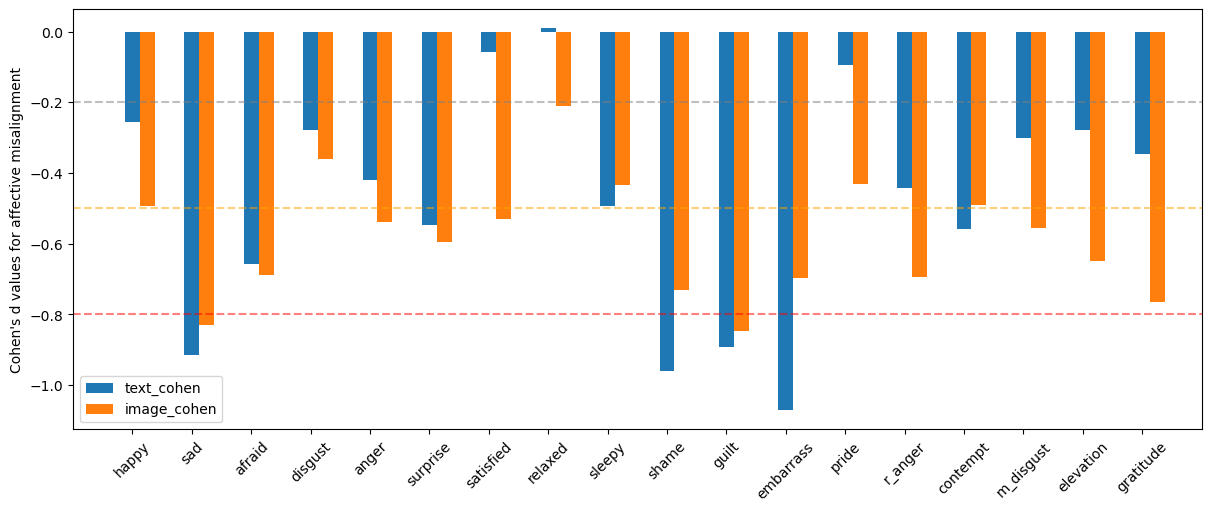

In [127]:
fig, ax = plt.subplots(layout='constrained', figsize = (12, 5))

format_cohen = {
    'text_cohen': (-0.2570450670664337, -0.913454560669566, -0.6576028805468321, -0.2770587804778312, -0.41870265372169807, -0.5476914365833351, -0.05856768077058476,
 0.008940101787021563, -0.4925131652652954, -0.9611902879329502, -0.8909704653114204, -1.0710078227279183, -0.09508491723584082, -0.4418795945877736,
 -0.5575471719293852, -0.299625516328956, -0.27823177568765817, -0.344900583866126),
    'image_cohen': (-0.4922381026201575, -0.8285762745524592, -0.6880247688605831, -0.36082742520695216, -0.5376760029170199, -0.5964978880508861, -0.5310334132210713,
 -0.21136107025353443, -0.43470933218262403, -0.7313077674161818, -0.8468622253669884, -0.6968066324994537, -0.43220556467959903, -0.6947341719324133, -0.4913982771689453,
 -0.5545796040478632, -0.6495190666386537, -0.7661656998699155)
}

x = np.arange(len(raw_emotion_order))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
ax.hlines([-0.2, -0.5, -0.8], xmin = -1, xmax = 25, linestyles = "dashed", colors = ["gray", "orange", "red"], alpha = 0.5)
for format, cohen in format_cohen.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, cohen, width, label=format)
    #ax.bar_label(rects, 2, padding=3)
    multiplier += 1
ax.set_xticks(np.arange(len(raw_emotion_order)))
ax.set_xticklabels(raw_emotion_order, rotation = 45)

ax.set_xlim(-1, 18)
plt.ylabel("Cohen's d values for affective misalignment")
plt.savefig("FIG3.eps", format='eps', dpi=300)
plt.legend()
plt.show()

In [76]:
df_emo_kor_mean

NameError: name 'df_emo_kor_mean' is not defined

In [604]:
rows_colinear_kor = []
for i, emo in enumerate(raw_emotion_order):
    ref = df_emo_kor_mean.iloc[i, :]    
    text_vecs  = np.array(globals()["text_response_{}".format(emo)].groupby(["participant"]).mean())             # (91, 4)
    image_vecs = np.array(globals()["image_response_{}".format(emo)].iloc[:, [1,2,3,4]])            # (91, 4)
    #row_colinear = test_H0_vs_zero(ref, text_vecs, image_vecs)
    #rows_colinear.append(row_colinear)
    t_s  = get_sims(ref, text_vecs)
    im_s = get_sims(ref, image_vecs)
 
    t_t,  t_p  = stats.ttest_1samp(t_s,  popmean=0, alternative="greater")
    im_t, im_p = stats.ttest_1samp(im_s, popmean=0, alternative="greater")
 
    rows_colinear_kor.append(dict(
        emotion        = emo,
        text_mean_sim  = t_s.mean(),
        text_sd        = t_s.std(ddof=1),
        text_t         = t_t,
        text_p         = t_p,
        image_mean_sim = im_s.mean(),
        image_sd       = im_s.std(ddof=1),
        image_t        = im_t,
        image_p        = im_p
        ))
df_colinear_kor = pd.DataFrame(rows_colinear_kor)
df_colinear_kor["text_p_fdr"] = fdr(df_colinear_kor["text_p"])
df_colinear_kor["image_p_fdr"] = fdr(df_colinear_kor["image_p"])
df_colinear_kor["text_colinear"] = df_colinear_kor["text_p_fdr"]  < ALPHA
df_colinear_kor["image_colinear"] = df_colinear_kor["image_p_fdr"] < ALPHA
df_colinear_kor

,emotion,text_mean_sim,text_sd,text_t,text_p,image_mean_sim,image_sd,image_t,image_p,text_p_fdr,image_p_fdr,text_colinear,image_colinear
0,happy,0.714143,0.291333,23.383850,2.603368e-40,0.424783,0.450795,8.988934,1.814930e-14,2.343031e-39,2.512980e-14,True,True
1,sad,0.612534,0.391235,14.935297,2.146736e-26,0.483618,0.381760,12.084586,7.599199e-21,5.520179e-26,2.279760e-20,True,True
2,afraid,0.629011,0.479877,12.503995,1.095694e-21,0.522889,0.336851,14.807874,3.722700e-26,1.972249e-21,3.350430e-25,True,True
3,disgust,0.579866,0.483425,11.442466,1.522129e-19,0.551037,0.396379,13.261456,3.475438e-23,2.283194e-19,1.251158e-22,True,True
4,anger,0.536625,0.502655,10.184063,5.926378e-17,0.532486,0.380202,13.360242,2.226353e-23,7.619629e-17,1.001859e-22,True,True
5,surprise,0.373013,0.380684,9.347171,3.258024e-15,0.219904,0.431902,4.857014,2.499891e-06,3.909628e-15,2.646944e-06,True,True
6,satisfied,0.759961,0.324344,22.351453,8.393563e-39,0.456394,0.440582,9.881743,2.514896e-16,4.315757e-38,4.115284e-16,True,True
7,relaxed,0.792050,0.278922,27.088848,2.376426e-45,0.666062,0.396938,16.007130,2.269391e-28,4.277567e-44,4.084904e-27,True,True
8,sleepy,0.694352,0.296860,22.312480,9.590572e-39,0.490803,0.422355,11.085370,8.181986e-19,4.315757e-38,2.017737e-18,True,True
9,shame,0.555518,0.502420,10.547559,1.047755e-17,0.495086,0.426788,11.065959,8.967720e-19,1.450738e-17,2.017737e-18,True,True


In [605]:
np.round(df_colinear_kor, 2)

,emotion,text_mean_sim,text_sd,text_t,text_p,image_mean_sim,image_sd,image_t,image_p,text_p_fdr,image_p_fdr,text_colinear,image_colinear
0,happy,0.71,0.29,23.38,0.0,0.42,0.45,8.99,0.0,0.0,0.0,True,True
1,sad,0.61,0.39,14.94,0.0,0.48,0.38,12.08,0.0,0.0,0.0,True,True
2,afraid,0.63,0.48,12.50,0.0,0.52,0.34,14.81,0.0,0.0,0.0,True,True
3,disgust,0.58,0.48,11.44,0.0,0.55,0.40,13.26,0.0,0.0,0.0,True,True
4,anger,0.54,0.50,10.18,0.0,0.53,0.38,13.36,0.0,0.0,0.0,True,True
5,surprise,0.37,0.38,9.35,0.0,0.22,0.43,4.86,0.0,0.0,0.0,True,True
6,satisfied,0.76,0.32,22.35,0.0,0.46,0.44,9.88,0.0,0.0,0.0,True,True
7,relaxed,0.79,0.28,27.09,0.0,0.67,0.40,16.01,0.0,0.0,0.0,True,True
8,sleepy,0.69,0.30,22.31,0.0,0.49,0.42,11.09,0.0,0.0,0.0,True,True
9,shame,0.56,0.50,10.55,0.0,0.50,0.43,11.07,0.0,0.0,0.0,True,True


In [610]:
compute_epsilon(between_sims, method = "percentile_75")


[Epsilon]
  Between-construct sim: mean=0.0191, sd=0.7032, min=-0.9911, max=0.9953
  epsilon (percentile_75) = 0.7662


0.7661601283379215

In [79]:
df_emo_kor_mean = pd.DataFrame(index = raw_emotion_order, columns = ["val", "aro", "foc", "dom"])
for i in range(18):
    emo = raw_emotion_order[i]
    data = kor_data[kor_data["emotion"] == emo].iloc[:, 1:5]
    data_mean = data.mean(axis = 0)
    df_emo_kor_mean.iloc[i, :] = data_mean

df_emo_kor_mean

,val,aro,foc,dom
happy,110.157895,-7.592105,-44.855263,-116.907895
sad,-86.934211,-36.868421,45.210526,-84.342105
afraid,-118.473684,80.868421,81.815789,-19.934211
disgust,-147.236842,57.039474,27.894737,75.092105
anger,-128.894737,108.842105,43.223684,37.592105
surprise,-7.881579,73.526316,37.460526,-22.052632
satisfied,139.973684,-41.434211,-85.315789,-113.25
relaxed,108.828947,-142.684211,-98.302632,-104.723684
sleepy,2.855263,-178.526316,15.75,-107.157895
shame,-136.473684,79.763158,74.328947,-78.447368


### Supplementary table 9. One-sample one-sided t-tests revealed that mean cosine similarities between evaluation group affective responses and validation group raw emotion vectors were significantly greater than zero for both text- and image-based formats, indicating non-orthogonal, collinear affective responses to LLM-generated stimuli

In [95]:
kor_alignment = []
for i in range(18):
    emo = raw_emotion_order[i]
    ref = df_emo_kor_mean.iloc[i, :]  
    text_vecs  = np.array(globals()["text_response_{}".format(emo)].groupby(["participant"]).mean())             # (91, 4)
    image_vecs = np.array(globals()["image_response_{}".format(emo)].iloc[:, [1,2,3,4]])            # (91, 4)

    text_mean,  text_sd,  text_sims  = mean_cosine_sim_to_ref(ref, text_vecs)
    image_mean, image_sd, image_sims = mean_cosine_sim_to_ref(ref, image_vecs)

    t_text,  p_text  = stats.ttest_1samp(text_sims,  popmean=0, alternative='greater')
    t_image, p_image = stats.ttest_1samp(image_sims, popmean=0, alternative='greater')

    kor_alignment.append({
        "emotion"       : emo,
        "text_mean_sim" : text_mean,
        "text_sd"       : text_sd,
        "text_t"        : t_text,
        "text_p"        : p_text,
        "text_pass"     : p_text < ALPHA,
        "image_mean_sim": image_mean,
        "image_sd"      : image_sd,
        "image_t"       : t_image,
        "image_p"       : p_image,
        "image_pass"    : p_image < ALPHA,
        })
df_alignment_kor = pd.DataFrame(kor_alignment)

df_alignment_kor["text_p_fdr"] = fdr(df_alignment_kor["text_p"])
df_alignment_kor["image_p_fdr"] = fdr(df_alignment_kor["image_p"])
df_alignment_kor["text_aligned"] = df_alignment_kor["text_p_fdr"]  < ALPHA
df_alignment_kor["image_aligned"] = df_alignment_kor["image_p_fdr"] < ALPHA

np.round(df_alignment_kor, 1)

,emotion,text_mean_sim,text_sd,text_t,text_p,text_pass,image_mean_sim,image_sd,image_t,image_p,image_pass,text_p_fdr,image_p_fdr,text_aligned,image_aligned
0,happy,0.7,0.3,23.4,0.0,True,0.4,0.5,9.0,0.0,True,0.0,0.0,True,True
1,sad,0.6,0.4,14.9,0.0,True,0.5,0.4,12.1,0.0,True,0.0,0.0,True,True
2,afraid,0.6,0.5,12.5,0.0,True,0.5,0.3,14.8,0.0,True,0.0,0.0,True,True
3,disgust,0.6,0.5,11.4,0.0,True,0.6,0.4,13.3,0.0,True,0.0,0.0,True,True
4,anger,0.5,0.5,10.2,0.0,True,0.5,0.4,13.4,0.0,True,0.0,0.0,True,True
5,surprise,0.4,0.4,9.3,0.0,True,0.2,0.4,4.9,0.0,True,0.0,0.0,True,True
6,satisfied,0.8,0.3,22.4,0.0,True,0.5,0.4,9.9,0.0,True,0.0,0.0,True,True
7,relaxed,0.8,0.3,27.1,0.0,True,0.7,0.4,16.0,0.0,True,0.0,0.0,True,True
8,sleepy,0.7,0.3,22.3,0.0,True,0.5,0.4,11.1,0.0,True,0.0,0.0,True,True
9,shame,0.6,0.5,10.5,0.0,True,0.5,0.4,11.1,0.0,True,0.0,0.0,True,True


In [82]:
results_kor = []
bc_std = np.std(between_sims)
for i, emo in enumerate(raw_emotion_order):
    ref = df_emo_kor_mean.iloc[i, :]    
    text_vecs  = np.array(globals()["text_response_{}".format(emo)].groupby(["participant"]).mean())             # (91, 4)
    image_vecs = np.array(globals()["image_response_{}".format(emo)].iloc[:, [1,2,3,4]])            # (91, 4)
 
    text_sims  = np.array([cosine_sim(ref, v) for v in text_vecs])
    image_sims = np.array([cosine_sim(ref, v) for v in image_vecs])
    
    for k in np.arange(0, 1.01, 0.01):
        text_mean, text_sd, text_cohend, tost_text = run_equivalence(text_sims, between_sims_75, bc_std, [k])
        image_mean, image_sd, image_cohend, tost_image = run_equivalence(image_sims, between_sims_75, bc_std, [k])
        
        results_kor.append({
            "emotion" : emo,
            "criterion" : "75 percentile",
            "epsilon" : between_sims_75,
            "epsilon multiplier" : k,
            "text-to-ref sim" : text_mean,
            "text-to-ref sim stdev" : text_sd,
            "text-to-ref-cohend" : text_cohend,
            "text post" : tost_text[k],
            "text equivalence" : tost_text[k] < 0.05,
            "image-to-ref sim" : image_mean,
            "image-to-ref sim stdev": image_sd,
            "image-to-ref-cohend": image_cohend,
            "image post": tost_image[k],
            "image equivalence" : tost_image[k] < 0.05
        })
df_equivalence_kor = pd.DataFrame(results_kor) 
df_equivalence_kor

,emotion,criterion,epsilon,epsilon multiplier,text-to-ref sim,text-to-ref sim stdev,text-to-ref-cohend,text post,text equivalence,image-to-ref sim,image-to-ref sim stdev,image-to-ref-cohend,image post,image equivalence
0,happy,75 percentile,0.76616,0.00,0.714143,0.291333,-0.088925,9.540137e-01,False,0.424783,0.450795,-0.549333,1.000000,False
1,happy,75 percentile,0.76616,0.01,0.714143,0.291333,-0.088925,9.278780e-01,False,0.424783,0.450795,-0.549333,1.000000,False
2,happy,75 percentile,0.76616,0.02,0.714143,0.291333,-0.088925,8.914006e-01,False,0.424783,0.450795,-0.549333,1.000000,False
3,happy,75 percentile,0.76616,0.03,0.714143,0.291333,-0.088925,8.429831e-01,False,0.424783,0.450795,-0.549333,1.000000,False
4,happy,75 percentile,0.76616,0.04,0.714143,0.291333,-0.088925,7.819229e-01,False,0.424783,0.450795,-0.549333,1.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1813,gratitude,75 percentile,0.76616,0.96,0.526898,0.399774,-0.393319,2.116749e-17,True,0.204583,0.408023,-0.920091,0.004702,True
1814,gratitude,75 percentile,0.76616,0.97,0.526898,0.399774,-0.393319,9.521343e-18,True,0.204583,0.408023,-0.920091,0.002966,True
1815,gratitude,75 percentile,0.76616,0.98,0.526898,0.399774,-0.393319,4.289541e-18,True,0.204583,0.408023,-0.920091,0.001837,True
1816,gratitude,75 percentile,0.76616,0.99,0.526898,0.399774,-0.393319,1.935871e-18,True,0.204583,0.408023,-0.920091,0.001118,True


In [83]:
emotion_epsilon_threshold_text_kor = {}
emotion_epsilon_threshold_image_kor ={}
for emo in raw_emotion_order:
    try:
        print(f"emotion {emo} : ", np.where(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["text equivalence"] == True)[0][0])
        print("mean cosine similarity {} , stdev {}, epsilon {}, mean - epsilon {}".format(np.unique(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["text-to-ref sim"])[0],
              np.unique(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["text-to-ref sim stdev"])[0],
              np.unique(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["epsilon"])[0],
              np.unique(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["text-to-ref sim"])[0] - np.unique(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["epsilon"])[0]
              ))
        emotion_epsilon_threshold_text_kor[emo] = np.where(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["text equivalence"] == True)[0][0]
    except:
        print(f"emotion {emo} does not pass equivalence testing across epsilon multiplier values 0 - 1")
        emotion_epsilon_threshold_text_kor[emo] = -1
print("==========================")
print("results for image-based communications")
print("==========================")
for emo in raw_emotion_order:
    try:
        print(f"emotion {emo} : ", np.where(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["image equivalence"] == True)[0][0])
        print("mean cosine similarity {} , stdev {}, epsilon {}, mean - epsilon {}".format(np.unique(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["image-to-ref sim"])[0],
              np.unique(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["image-to-ref sim stdev"])[0],
              np.unique(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["epsilon"])[0],
              np.unique(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["image-to-ref sim"])[0] - np.unique(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["epsilon"])[0]
              ))
        emotion_epsilon_threshold_image_kor[emo] = np.where(df_equivalence_kor[df_equivalence_kor["emotion"] == emo]["image equivalence"] == True)[0][0]
    except:
        print(f"emotion {emo} does not pass equivalence testing across epsilon multiplier values 0 - 1")
        emotion_epsilon_threshold_image_kor[emo] = -1

emotion happy :  15
mean cosine similarity 0.7141429101741609 , stdev 0.2913330901900562, epsilon 0.7661601283379215, mean - epsilon -0.05201721816376059
emotion sad :  32
mean cosine similarity 0.6125341966366111 , stdev 0.391234530425221, epsilon 0.7661601283379215, mean - epsilon -0.15362593170131034
emotion afraid :  32
mean cosine similarity 0.6290110247039516 , stdev 0.4798772578571549, epsilon 0.7661601283379215, mean - epsilon -0.13714910363396982
emotion disgust :  39
mean cosine similarity 0.5798661986947024 , stdev 0.48342472190625957, epsilon 0.7661601283379215, mean - epsilon -0.1862939296432191
emotion anger :  46
mean cosine similarity 0.536624799125819 , stdev 0.5026554007104633, epsilon 0.7661601283379215, mean - epsilon -0.2295353292121025
emotion surprise :  66
mean cosine similarity 0.37301284746659646 , stdev 0.380683715680779, epsilon 0.7661601283379215, mean - epsilon -0.393147280871325
emotion satisfied :  9
mean cosine similarity 0.7599609864146953 , stdev 0.32

In [84]:
text_names_kor = list(emotion_epsilon_threshold_text_kor.keys())
text_values_kor = list(emotion_epsilon_threshold_text_kor.values())
image_names_kor = list(emotion_epsilon_threshold_image_kor.keys())
image_values_kor = list(emotion_epsilon_threshold_image_kor.values())
text_cohend_kor = list(df_equivalence_kor[df_equivalence_kor["epsilon multiplier"] == 0.00]["text-to-ref-cohend"])
image_cohend_kor = list(df_equivalence_kor[df_equivalence_kor["epsilon multiplier"] == 0.00]["image-to-ref-cohend"])

In [89]:
format_cohen_kor = {
    'text_cohen': (-0.08892458211200722, -0.25340446752694284, -0.21787440337709502, -0.29547218787723467, -0.3608684228463601, -0.6511813522517798, -0.010482425232457359,
 0.04443015664734459, -0.12254198717754346, -0.3312003536879239, -0.3263788347886742, -0.20480000884915495, -0.050370136747412565, -0.6655385427497452, -0.4217069230814011,
 -0.5020904701026532, -0.3464032305651677, -0.3933191204152191),
    'image_cohen': (-0.549332891604479, -0.46778767030496526, -0.4095622717253555, -0.3541183163648584, -0.38711282333358327, -0.8861609159642299, -0.5006647840249591,
 -0.16473584613984085, -0.44849034693419776, -0.44069613250610634, -0.5411582692457921, -0.6126500963532966, -0.43662887097650505, -0.6685679311174486,
 -0.41363398607339796, -0.6659768916697686, -0.6043499541696711, -0.9200905511492877)
}

### Supplementary figure 3. Cohen's d effect sizes of the difference between validation-to-evaluation group affective alignment and the semantic alignment threshold (ε)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


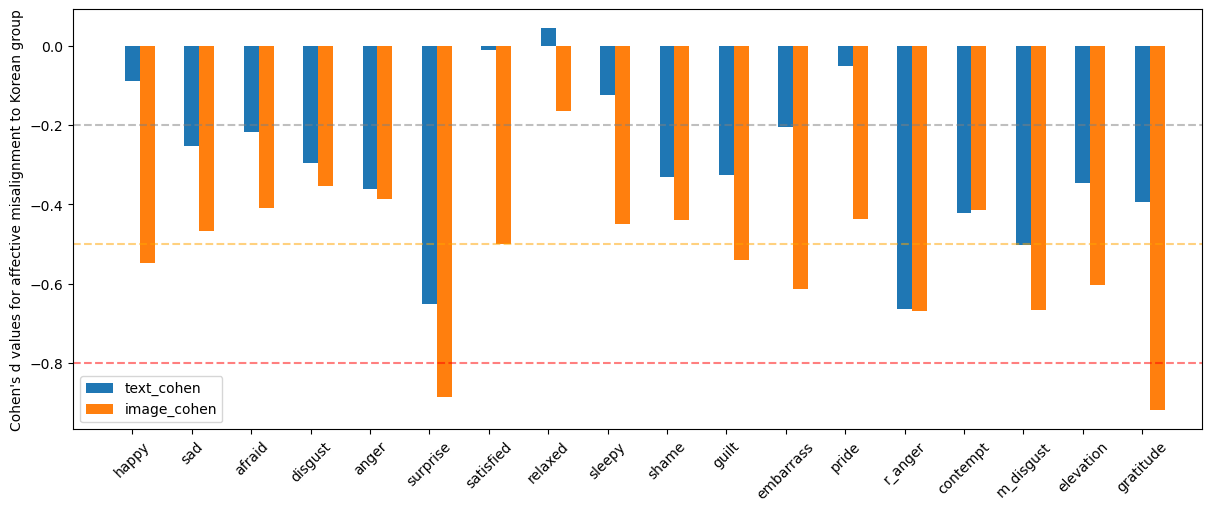

In [ ]:
fig, ax = plt.subplots(layout='constrained', figsize = (12, 5))

x = np.arange(len(raw_emotion_order))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
ax.hlines([-0.2, -0.5, -0.8], xmin = -1, xmax = 25, linestyles = "dashed", colors = ["gray", "orange", "red"], alpha = 0.5)
for format, cohen in format_cohen_kor.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, cohen, width, label=format)
    #ax.bar_label(rects, 2, padding=3)
    multiplier += 1
ax.set_xticks(np.arange(len(raw_emotion_order)))
ax.set_xticklabels(raw_emotion_order, rotation = 45)

ax.set_xlim(-1, 18)
plt.ylabel("Cohen's d values for affective misalignment to Korean group")

plt.legend()
plt.show()

### Cohen's d comparison between cross-lingual and same-language conditions

In [102]:
cross_cohen = [-0.2570450670664337, -0.913454560669566, -0.6576028805468321, -0.2770587804778312, -0.41870265372169807, -0.5476914365833351, -0.05856768077058476,
 0.008940101787021563, -0.4925131652652954, -0.9611902879329502, -0.8909704653114204, -1.0710078227279183, -0.09508491723584082, -0.4418795945877736,
 -0.5575471719293852, -0.299625516328956, -0.27823177568765817, -0.344900583866126, -0.4922381026201575, -0.8285762745524592, -0.6880247688605831, -0.36082742520695216, -0.5376760029170199, -0.5964978880508861, -0.5310334132210713,
 -0.21136107025353443, -0.43470933218262403, -0.7313077674161818, -0.8468622253669884, -0.6968066324994537, -0.43220556467959903, -0.6947341719324133, -0.4913982771689453,
 -0.5545796040478632, -0.6495190666386537, -0.7661656998699155]
same_cohen = [-0.08892458211200722, -0.25340446752694284, -0.21787440337709502, -0.29547218787723467, -0.3608684228463601, -0.6511813522517798, -0.010482425232457359,
 0.04443015664734459, -0.12254198717754346, -0.3312003536879239, -0.3263788347886742, -0.20480000884915495, -0.050370136747412565, -0.6655385427497452, -0.4217069230814011,
 -0.5020904701026532, -0.3464032305651677, -0.3933191204152191, -0.549332891604479, -0.46778767030496526, -0.4095622717253555, -0.3541183163648584, -0.38711282333358327, -0.8861609159642299, -0.5006647840249591,
 -0.16473584613984085, -0.44849034693419776, -0.44069613250610634, -0.5411582692457921, -0.6126500963532966, -0.43662887097650505, -0.6685679311174486,
 -0.41363398607339796, -0.6659768916697686, -0.6043499541696711, -0.9200905511492877]
u_cohen, p_cohen = mannwhitneyu(cross_cohen,  same_cohen)
print("cross-lingual Cohen's d values, mean : ", np.mean(cross_cohen), " stdev : ", np.std(cross_cohen))
print("same-language Cohen's d values, mean : ", np.mean(same_cohen), " stdev : ", np.std(same_cohen))
print("Mann-whitney results : ", u_cohen, p_cohen)

cross-lingual Cohen's d values, mean :  -0.5305182651779967  stdev :  0.2540110577820637
same-language Cohen's d values, mean :  -0.4074957178444214  stdev :  0.2212903022427909
Mann-whitney results :  461.0 0.03569217329473572


In [98]:
text_sims_raw

NameError: name 'text_sims_raw' is not defined

text happy NORMAL, p val :  0.6205942630767822
image happy NORMAL, p val :  0.07678860425949097
text sad NOT normal, p val :  0.0002840594679582864
image sad NOT normal, p val :  0.0003907513164449483
text afraid NOT normal, p val :  0.00024183819186873734
image afraid NOT normal, p val :  4.406901643960737e-05
text disgust NOT normal, p val :  1.3105813195579685e-05
image disgust NORMAL, p val :  0.6161196827888489
text anger NORMAL, p val :  0.5555873513221741
image anger NOT normal, p val :  0.007153534330427647
text surprise NORMAL, p val :  0.6566672921180725
image surprise NOT normal, p val :  0.0054007950238883495
text satisfied NOT normal, p val :  0.0009313896880485117
image satisfied NORMAL, p val :  0.07059219479560852
text relaxed NOT normal, p val :  0.016466807574033737
image relaxed NOT normal, p val :  0.016769686713814735
text sleepy NORMAL, p val :  0.8760353326797485
image sleepy NORMAL, p val :  0.110404834151268
text shame NOT normal, p val :  8.491245353070553e-06

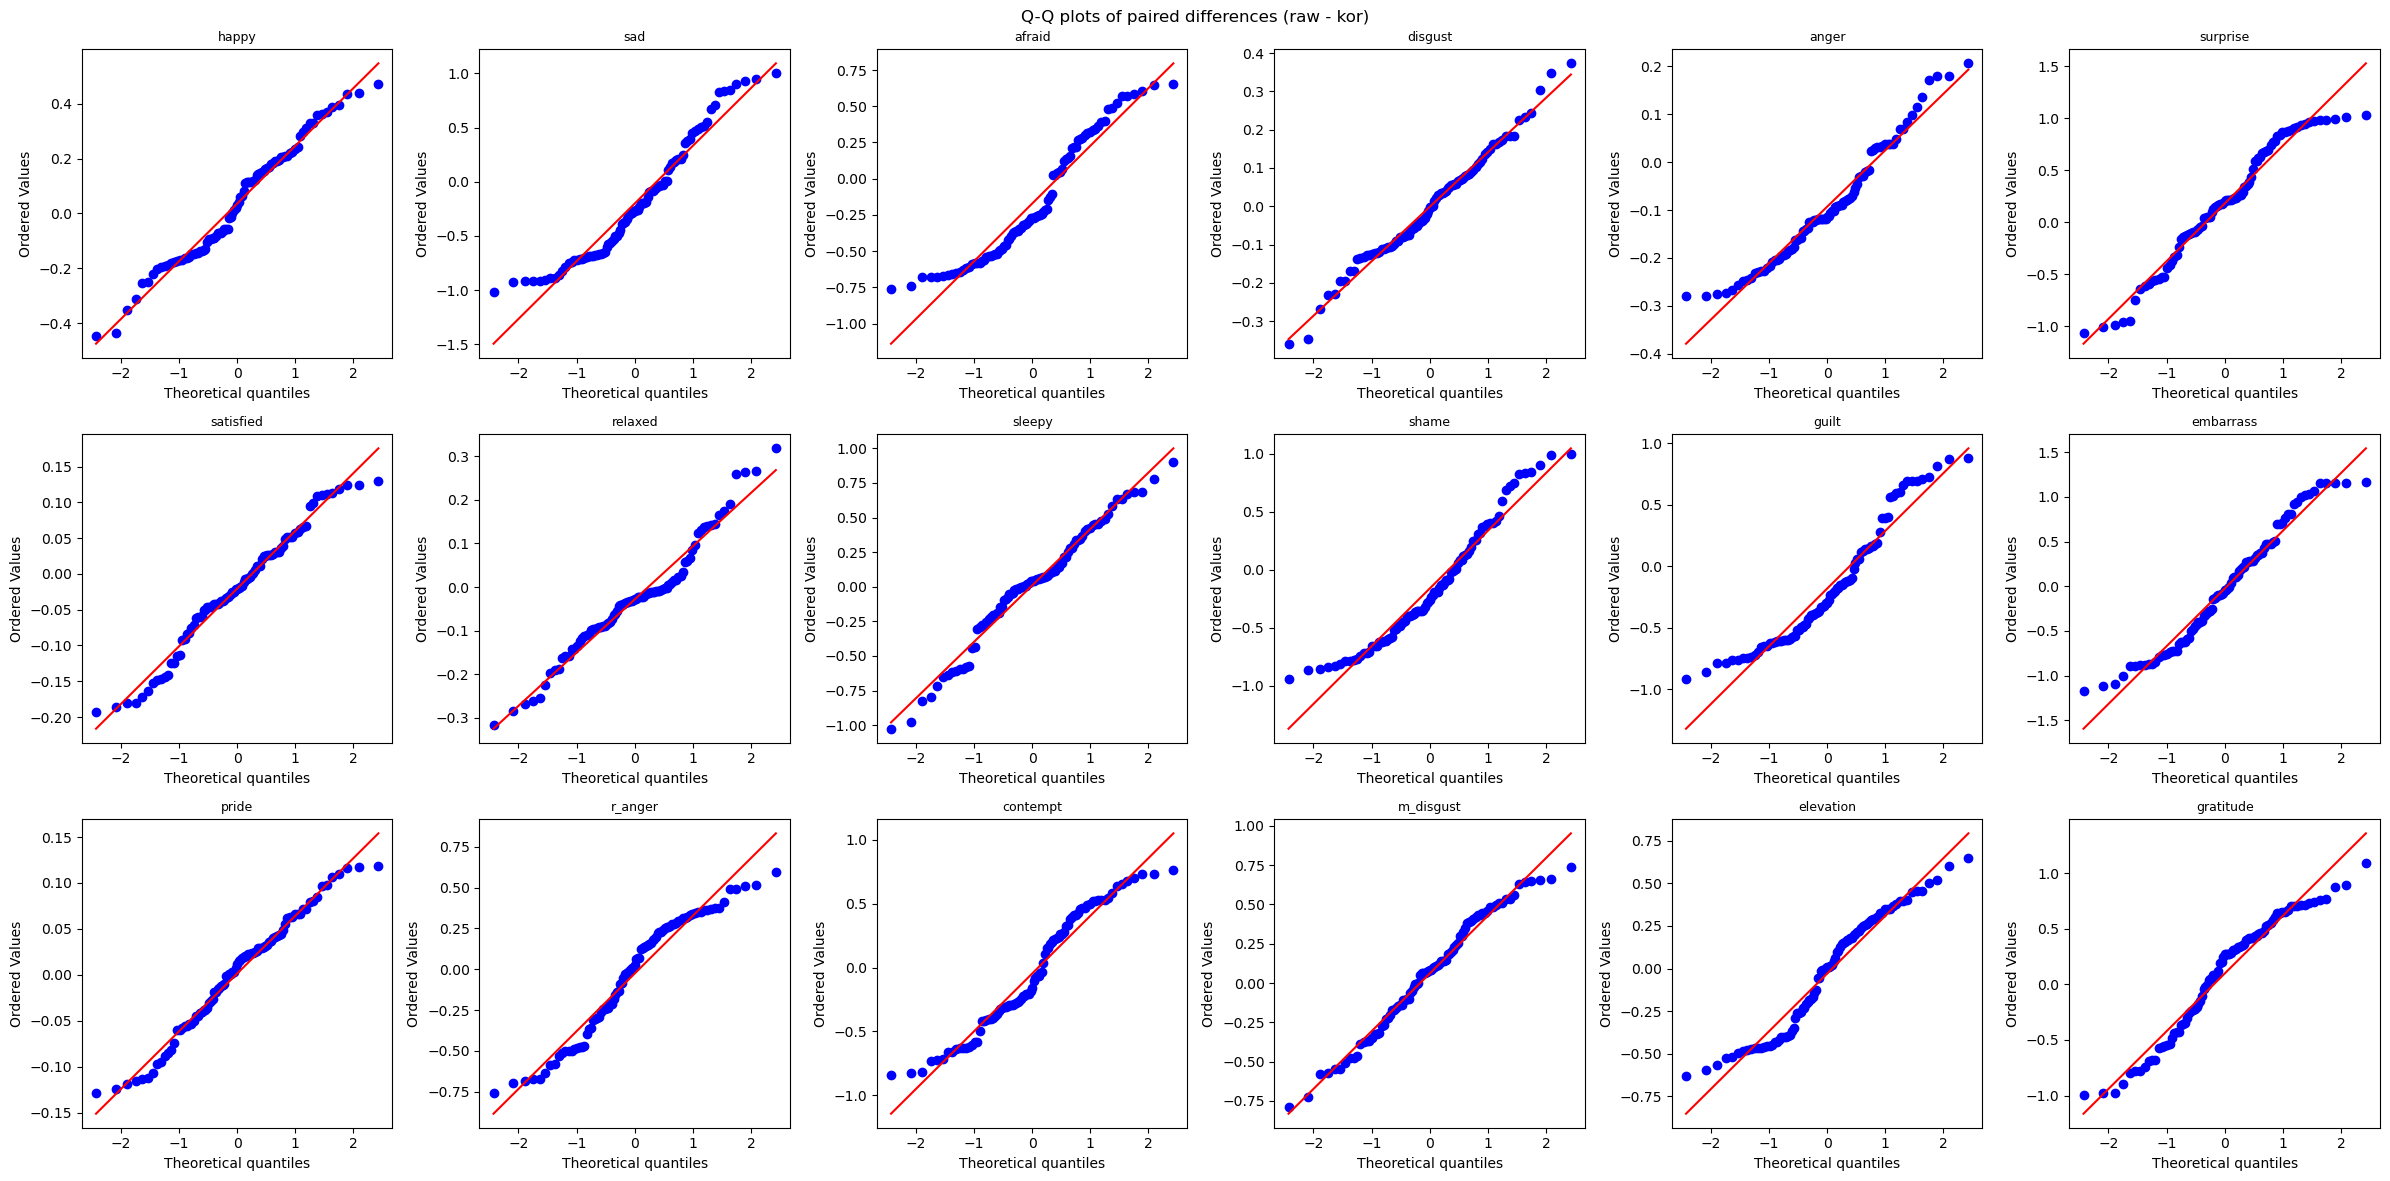

In [502]:
fig, axes = plt.subplots(3, 6, figsize=(24, 12))
axes = axes.flatten()
for i, emo in enumerate(raw_emotion_order):
    ref1 = df_emo_raw_mean.iloc[i, :]
    ref2 = df_emo_kor_mean.iloc[i, :]    
    text_vecs  = np.array(globals()["text_response_{}".format(emo)].groupby(["participant"]).mean())             # (91, 4)
    image_vecs = np.array(globals()["image_response_{}".format(emo)].iloc[:, [1,2,3,4]])            # (91, 4)
 
    text_sims_raw  = np.array([cosine_sim(ref1, v) for v in text_vecs])
    image_sims_raw = np.array([cosine_sim(ref1, v) for v in image_vecs])

    text_sims_kor  = np.array([cosine_sim(ref2, v) for v in text_vecs])
    image_sims_kor = np.array([cosine_sim(ref2, v) for v in image_vecs])

    stat_diff_text, p_normal_diff_text = stats.shapiro(text_sims_raw - text_sims_kor)
    stat_diff_image, p_normal_diff_image = stats.shapiro(image_sims_raw - image_sims_kor)

    if p_normal_diff_text < 0.05:
        print(f"text {emo} NOT normal, p val : ", p_normal_diff_text)
    else:
        print(f"text {emo} NORMAL, p val : ", p_normal_diff_text)

    if p_normal_diff_image < 0.05:
        print(f"image {emo} NOT normal, p val : ", p_normal_diff_image)
    else:
        print(f"image {emo} NORMAL, p val : ", p_normal_diff_image)

    diff = image_sims_raw - image_sims_kor  # (91,)
    stats.probplot(diff, dist="norm", plot=axes[i])
    axes[i].set_title(emo, fontsize=9)
plt.suptitle("Q-Q plots of paired differences (raw - kor)", fontsize=12)
plt.tight_layout()

### Figure 4. Pairwise differences in cosine similarity between cross-lingual and same-language affective alignment (cross-lingual minus same-language) per emotion construct and stimulus format

In [103]:
results_cross = []
for i, emo in enumerate(raw_emotion_order):
    ref1 = df_emo_raw_mean.iloc[i, :]
    ref2 = df_emo_kor_mean.iloc[i, :]    
    text_vecs  = np.array(globals()["text_response_{}".format(emo)].groupby(["participant"]).mean())             # (91, 4)
    image_vecs = np.array(globals()["image_response_{}".format(emo)].iloc[:, [1,2,3,4]])            # (91, 4)
 
    text_sims_raw  = np.array([cosine_sim(ref1, v) for v in text_vecs])
    image_sims_raw = np.array([cosine_sim(ref1, v) for v in image_vecs])

    text_sims_kor  = np.array([cosine_sim(ref2, v) for v in text_vecs])
    image_sims_kor = np.array([cosine_sim(ref2, v) for v in image_vecs])

    stat_diff_text, p_normal_diff_text = stats.shapiro(text_sims_raw - text_sims_kor)
    if p_normal_diff_text < 0.05:
        stat1, p_val1 =  wilcoxon(text_sims_raw, text_sims_kor)
    else:
        stat1, p_val1 = stats.ttest_rel(text_sims_raw, text_sims_kor)

    stat_diff_image, p_normal_diff_image = stats.shapiro(image_sims_raw - image_sims_kor)
    if p_normal_diff_image < 0.05:
        stat2, p_val2 = wilcoxon(image_sims_raw, image_sims_kor)
    else:
        stat2, p_val2 = stats.ttest_rel(image_sims_raw, image_sims_kor)

    cs_diff_text = np.mean(text_sims_raw - text_sims_kor)
    cs_diff_text_std = np.std(text_sims_raw - text_sims_kor)
    cs_diff_image = np.mean(image_sims_raw - image_sims_kor)
    cs_diff_image_std = np.std(image_sims_raw - image_sims_kor)
    
    cohend_text = np.mean(text_sims_raw - text_sims_kor) / np.std(text_sims_raw - text_sims_kor)
    cohend_image = np.mean(image_sims_raw - image_sims_kor) / np.std(image_sims_raw - image_sims_kor)

    results_cross.append({
        "emotion" : emo,
        "T_text or W_text" : stat1,
        "P_text" : p_val1,
        "parametric_text" : 0 if p_normal_diff_text < 0.05 else 1,
        "delta_similarity_text": cs_diff_text,
        "delta_stdev_text" : cs_diff_text_std,
        "cohend_text": cohend_text,
        "T_image or W_image" : stat2,
        "P_image" : p_val2,
        "parametric_image" : 0 if p_normal_diff_image < 0.05 else 1,
        "delta_similarity_image": cs_diff_image,
        "delta_stdev_image" : cs_diff_image_std,
        "cohend_image": cohend_image
    })
#plt.savefig("qq_plots.png", dpi=150, bbox_inches="tight")
df_cross = pd.DataFrame(results_cross)
df_cross["text_p_fdr"] = np.round(fdr(df_cross["P_text"]), 3)
df_cross["image_p_fdr"] =  np.round(fdr(df_cross["P_image"]), 3)
df_cross["text_diff_sig"] = df_cross["text_p_fdr"]  < ALPHA
df_cross["image_diff_sig"] = df_cross["image_p_fdr"] < ALPHA
np.round(df_cross, 2)

,emotion,T_text or W_text,P_text,parametric_text,delta_similarity_text,delta_stdev_text,cohend_text,T_image or W_image,P_image,parametric_image,delta_similarity_image,delta_stdev_image,cohend_image,text_p_fdr,image_p_fdr,text_diff_sig,image_diff_sig
0,happy,-6.19,0.00,1,-0.10,0.15,-0.65,1.65,0.10,1,0.04,0.21,0.17,0.00,0.18,True,False
1,sad,468.00,0.00,0,-0.40,0.42,-0.95,1239.00,0.00,0,-0.20,0.54,-0.38,0.00,0.00,True,True
2,afraid,506.00,0.00,0,-0.27,0.31,-0.88,1147.00,0.00,0,-0.17,0.40,-0.42,0.00,0.00,True,True
3,disgust,2091.00,0.99,0,0.02,0.13,0.13,-0.10,0.92,1,-0.00,0.14,-0.01,0.99,0.92,False,False
4,anger,-3.29,0.00,1,-0.04,0.10,-0.35,593.00,0.00,0,-0.09,0.12,-0.79,0.00,0.00,True,True
5,surprise,1.41,0.16,1,0.05,0.36,0.15,1317.00,0.00,0,0.18,0.55,0.33,0.18,0.01,False,True
6,satisfied,1183.00,0.00,0,-0.03,0.07,-0.43,-2.44,0.02,1,-0.02,0.08,-0.26,0.00,0.04,True,True
7,relaxed,1426.00,0.01,0,-0.02,0.10,-0.21,1351.00,0.00,0,-0.03,0.12,-0.23,0.01,0.01,True,True
8,sleepy,-6.46,0.00,1,-0.22,0.33,-0.68,0.24,0.81,1,0.01,0.40,0.02,0.00,0.86,True,False
9,shame,539.00,0.00,0,-0.38,0.44,-0.87,1332.00,0.00,0,-0.16,0.50,-0.32,0.00,0.01,True,True


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


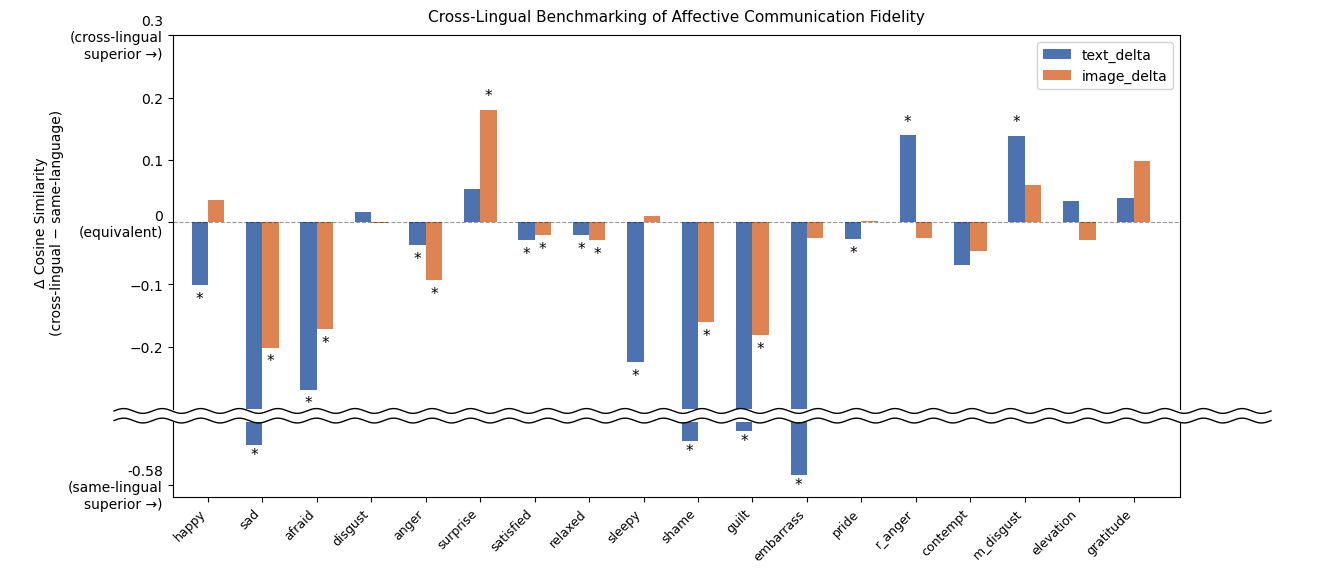

In [130]:
import matplotlib.gridspec as gridspec

format_delta = {
    'text_delta': (-0.10081215121448535, -0.40173018736844773, -0.2686591720704576, 0.016373147077908448, -0.03619993924286481, 0.05379498393426295,
 -0.028916368491759756, -0.020638504783521302, -0.22425073811576685, -0.38288355903920884, -0.3380988962012146, -0.5335803733085969,
 -0.027428074200007386, 0.13910553696193972, -0.0683618705506657, 0.13880354571904793, 0.03441334161283807, 0.0389158750660812),
    'image_delta': (0.0362926070667324, -0.2012634142118606, -0.17153871551880565, -0.0014043002937613894, -0.09292328873924582, 0.17999262671573057,
 -0.02046913999443709, -0.028414551152270363, 0.010038528746450066, -0.16107527381975306, -0.1809340255375898, -0.025520453900485345,
 0.0015726366066441263, -0.0260423648357657, -0.046983207518364024, 0.06032481961092028, -0.029417190425987134, 0.09754749828722982)
}

# Find the most negative value to set break range
min_val   = min(min(format_delta["text_delta"]), min(format_delta["image_delta"]))
break_lo  = min_val - 0.10          # a little padding below minimum
break_hi  = -0.30                   # where the break starts
main_lo   = -0.30
main_hi   =  0.30
 
fig = plt.figure(figsize=(13, 6))
gs  = gridspec.GridSpec(2, 1,
                        height_ratios=[5, 1],   # main is much taller
                        hspace=0.06)
 
ax_main  = fig.add_subplot(gs[0])
ax_break = fig.add_subplot(gs[1])
 
# =============================================================================
# Bar plots on both axes
# =============================================================================
 
x     = np.arange(len(raw_emotion_order))
width = 0.30
colors = {"text_delta": "#4C72B0", "image_delta": "#DD8452"}
 
for ax in [ax_main, ax_break]:
    for i, (fmt, delta) in enumerate(format_delta.items()):
        offset = width * i
        ax.bar(x + offset, delta, width,
               color=colors[fmt],
               label=fmt if ax is ax_main else None)

def add_asterisks(ax, sig_series, delta_series, x_positions, offset,
                  ylim_top, fontsize=11):
    """Place '*' just above (positive) or below (negative) each significant bar."""
    for idx, (sig, val) in enumerate(zip(sig_series, delta_series)):
        if not sig:
            continue
        bar_top = val
        # only draw on this axis if the bar top is within its ylim
        lo, hi = ax.get_ylim()
        if lo <= bar_top <= hi:
            y_pos = bar_top + (0.01 if bar_top >= 0 else -0.01)
            ax.text(x_positions[idx] + offset, y_pos, "*",
                    ha="center", va="bottom" if bar_top >= 0 else "top",
                    fontsize=fontsize, color="black")
 
# Set ylims first so add_asterisks can test membership
ax_main.set_ylim(main_lo, main_hi)
ax_break.set_ylim(break_lo, break_hi)

for i, (fmt, sig_col) in enumerate(
        [("delta_similarity_text",  "text_diff_sig"),
         ("delta_similarity_image", "image_diff_sig")]):
    offset = width * i
    add_asterisks(ax_main,  df_cross[sig_col], df_cross[fmt], x, offset, main_hi)
    add_asterisks(ax_break, df_cross[sig_col], df_cross[fmt], x, offset, break_hi)


# =============================================================================
# Axes appearance
# =============================================================================
 
# --- main axes ---
ax_main.spines["bottom"].set_visible(False)
ax_main.tick_params(bottom=False, labelbottom=False)
ax_main.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax_main.set_xlim(-0.5, 18)
ax_main.set_yticks([-0.2, -0.1, 0, 0.1, 0.2, 0.3])
ax_main.set_yticklabels([
    "−0.2", 
    "−0.1",
    "0\n(equivalent)",
    "0.1",
    "0.2",
    "0.3\n(cross-lingual\nsuperior →)"
])
ax_main.set_ylabel("Δ Cosine Similarity\n(cross-lingual − same-language)",
                   fontsize=10)
ax_main.set_title("Cross-Lingual Benchmarking of Affective Communication Fidelity",
                  fontsize=11, pad=10)
ax_main.legend(loc="upper right", framealpha=0.85)
 
# --- break axes ---
ax_break.spines["top"].set_visible(False)
ax_break.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax_break.set_xlim(-0.5, 18)
ax_break.set_xticks(x + width / 2)
ax_break.set_xticklabels(raw_emotion_order, rotation=45, ha="right", fontsize=9)
# 
# show only the most extreme ytick in break panel
ax_break.set_yticks([round(break_lo + 0.05, 2)])
ax_break.set_yticklabels([f"{round(break_lo + 0.05, 2)}\n(same-lingual\nsuperior →)"],
                          fontsize=10)

# =============================================================================
# Broken-axis diagonal markers (~~)
# =============================================================================
 
fig.canvas.draw()
 
inv    = fig.transFigure.inverted()
 
# ax_main 하단과 ax_break 상단의 figure 좌표
main_bottom_fig = inv.transform(ax_main.transAxes.transform([0, 0]))[1]
break_top_fig   = inv.transform(ax_break.transAxes.transform([0, 1]))[1]
 
# 두 axes 사이 중앙
gap_center = (main_bottom_fig + break_top_fig) / 2
 
# 흰색 배경 띠로 axes 사이 gap을 완전히 채움
from matplotlib.patches import Rectangle
gap_height = break_top_fig - main_bottom_fig + 0.01
white_band = Rectangle(
    (0, main_bottom_fig - 0.005), 1, gap_height,
    transform=fig.transFigure,
    color="white", zorder=8, clip_on=False
)
fig.add_artist(white_band)
 
# 물결선 두 줄 (gap 중앙 위아래로 살짝 오프셋)
amplitude = 0.004
n_waves   = 60
x_wave    = np.linspace(0.08, 0.97, n_waves * 20)
 
for y_center in [gap_center - 0.008, gap_center + 0.008]:
    y_wave = y_center + amplitude * np.sin(
        np.linspace(0, n_waves * np.pi, len(x_wave))
    )
    fig.add_artist(
        plt.Line2D(x_wave, y_wave,
                   transform=fig.transFigure,
                   color="black", linewidth=1.0,
                   clip_on=False, zorder=9)
    )

# =============================================================================
# Save
# =============================================================================
plt.savefig("FIG4.eps", format='eps', dpi=300)